# U-Net Diagnostic Evaluation
**WorldView-2/3 | 4-band (R,G,B,NIR1) | 512×512 chips | 4,788 held-out test chips**

Evaluates two U-Net inference strategies on the held-out test set and compares against baselines:
- **Best single fold** — `best_model.pth` (global best val loss across all 5 folds, fold 5)
- **Ensemble (majority vote)** — all 5 fold models apply their own val-selected threshold; a pixel is water if 3 or more models predict water

This notebook:
1. Runs inference for both strategies and saves probability maps
2. Finds optimal threshold for each strategy via sweep on validation data (never test set)
3. Analyses per-scene performance for both strategies
4. Inspects probability distributions (water vs land pixels)
5. Visually inspects best, middle and worst scenes
6. Saves a final summary CSV for use in comparison_all_final.ipynb

NOTE: Do not re-run cells 1–2 once results are saved — delete prob_maps_best/ or pred_maps_ensemble_majority/ to rerun inference.
NOTE: Threshold selection uses the exact same fold reconstruction as training (sklearn KFold with shuffle=True, random_state=42, preceded by random.seed(42) + random.shuffle).

In [1]:
# ── Cell 1: Setup ──
import json, torch
import numpy as np
import rasterio
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from sklearn.metrics import f1_score, jaccard_score, precision_score, recall_score
from tqdm import tqdm
import segmentation_models_pytorch as smp

BASE_DIR   = Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask')
CHIPS_DIR  = BASE_DIR / 'images/chips_images/images'
MASKS_DIR  = BASE_DIR / 'images/chips_masks/masks'
KFOLD_DIR  = BASE_DIR / 'results/unet_training_v3/kfold'
NORM_STATS = BASE_DIR / 'results/unet_training/normalisation_stats.json'
OUTPUT_DIR = BASE_DIR / 'results/unet_diagnostic_v3'
PROB_DIR_BEST     = OUTPUT_DIR / 'prob_maps_best'
PROB_DIR_ENSEMBLE = OUTPUT_DIR / 'prob_maps_ensemble'

for d in [OUTPUT_DIR, PROB_DIR_BEST, PROB_DIR_ENSEMBLE]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IN_CHANNELS = 4
N_FOLDS     = 5

# Load test chips
with open(BASE_DIR / 'results/unet_training/test_chips.json') as f:
    test_chip_names = json.load(f)
test_chips = [CHIPS_DIR / n for n in test_chip_names]

# Load normalisation stats
with open(NORM_STATS) as f:
    stats = json.load(f)
mean_all = np.array(stats['mean'], dtype=np.float32)
std_all  = np.array(stats['std'],  dtype=np.float32)
# Stats already computed for 4 bands in order: R, G, B, NIR1
mean = mean_all
std  = std_all
mean_t = torch.tensor(mean).view(4,1,1).to(DEVICE)
std_t  = torch.tensor(std).view(4,1,1).to(DEVICE)

def get_scene_id(filename):
    name = Path(filename).stem
    if '_clipped_' in name: return name.split('_clipped_')[0]
    if '_clip_' in name:    return name.split('_clip_')[0]
    return name

def load_model(path):
    model = smp.Unet(
        encoder_name='resnet34', encoder_weights=None,
        in_channels=IN_CHANNELS, classes=1, activation=None,
    ).to(DEVICE)
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.eval()
    return model

# Load best single fold model
best_model = load_model(KFOLD_DIR / 'best_model.pth')

# Load all fold models for ensemble
fold_models = []
for fold in range(1, N_FOLDS + 1):
    fold_path = KFOLD_DIR / f'fold{fold}_best.pth'
    fold_models.append(load_model(fold_path))
    print(f'Loaded fold {fold} model from {fold_path}')

print(f'\nBest model loaded: {KFOLD_DIR / "best_model.pth"}')
print(f'Ensemble models:   {N_FOLDS} folds')
print(f'Test chips:        {len(test_chips):,}')
print(f'Device:            {DEVICE}')

Loaded fold 1 model from /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/unet_training_v3/kfold/fold1_best.pth
Loaded fold 2 model from /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/unet_training_v3/kfold/fold2_best.pth
Loaded fold 3 model from /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/unet_training_v3/kfold/fold3_best.pth
Loaded fold 4 model from /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/unet_training_v3/kfold/fold4_best.pth
Loaded fold 5 model from /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/unet_training_v3/kfold/fold5_best.pth

Best model loaded: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/unet_training_v3/kfold/best_model.pth
Ens

In [5]:
# ── Cell 2: Run Inference — Save Probability Maps ──
# Runs inference for both best single fold and ensemble.
# Saves raw sigmoid probabilities for each strategy separately.
# Skip if already computed — delete prob_maps_best/ or prob_maps_ensemble/ to rerun.

print('Running inference on test chips...')
chip_stats = []

with torch.no_grad():
    for chip_path in tqdm(test_chips):
        mask_path = MASKS_DIR / chip_path.name

        with rasterio.open(chip_path) as src:
            image   = np.stack([src.read(5), src.read(3), src.read(2), src.read(7)]).astype(np.float32)
            profile = src.profile.copy()
        profile.update(count=1, dtype='float32', nodata=None)

        image_t = (torch.from_numpy(image).to(DEVICE) - mean_t) / std_t

        # ── Best single fold ──
        prob_path_best = PROB_DIR_BEST / chip_path.name
        if not prob_path_best.exists():
            prob_best = torch.sigmoid(best_model(image_t.unsqueeze(0))).squeeze().cpu().numpy()
            with rasterio.open(prob_path_best, 'w', **profile) as dst:
                dst.write(prob_best[np.newaxis, :, :])
        else:
            with rasterio.open(prob_path_best) as src:
                prob_best = src.read(1)

        # ── Ensemble ──
        prob_path_ens = PROB_DIR_ENSEMBLE / chip_path.name
        if not prob_path_ens.exists():
            probs = []
            for fm in fold_models:
                p = torch.sigmoid(fm(image_t.unsqueeze(0))).squeeze().cpu().numpy()
                probs.append(p)
            prob_ens = np.mean(probs, axis=0)
            with rasterio.open(prob_path_ens, 'w', **profile) as dst:
                dst.write(prob_ens[np.newaxis, :, :])
        else:
            with rasterio.open(prob_path_ens) as src:
                prob_ens = src.read(1)

        with rasterio.open(mask_path) as src:
            truth = (src.read(1) > 0).astype(np.uint8)

        chip_stats.append({
            'chip':            chip_path.name,
            'scene':           get_scene_id(chip_path.name),
            'water_frac':      float(truth.mean()),
            'prob_mean_best':  float(prob_best.mean()),
            'prob_mean_ens':   float(prob_ens.mean()),
        })

df_stats = pd.DataFrame(chip_stats)
df_stats.to_csv(OUTPUT_DIR / 'chip_stats.csv', index=False)

water_chips = df_stats[df_stats['water_frac'] > 0]
land_chips  = df_stats[df_stats['water_frac'] == 0]

print(f'\nChips with water: {len(water_chips):,} / {len(test_chips):,}')
print(f'\nBest model — mean prob water: {water_chips["prob_mean_best"].mean():.4f} | land: {land_chips["prob_mean_best"].mean():.4f}')
print(f'Ensemble   — mean prob water: {water_chips["prob_mean_ens"].mean():.4f} | land: {land_chips["prob_mean_ens"].mean():.4f}')

Running inference on test chips...


100%|██████████| 4788/4788 [45:51<00:00,  1.74it/s]


Chips with water: 1,025 / 4,788

Best model — mean prob water: 0.1004 | land: 0.0045
Ensemble   — mean prob water: 0.1018 | land: 0.0061


In [2]:
# ── Cell 3 — Threshold Selection on Fold 5 Val Scenes ──
import random, json, torch, rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from sklearn.model_selection import KFold
from tqdm import tqdm
import segmentation_models_pytorch as smp

SEED    = 42
N_FOLDS = 5
FOLD_NUM = 5

BASE_DIR  = Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask')
CHIPS_DIR = BASE_DIR / 'images/chips_images/images'
MASKS_DIR = BASE_DIR / 'images/chips_masks/masks'
KFOLD_DIR = BASE_DIR / 'results/unet_training_v3/kfold'
DIAG_DIR  = BASE_DIR / 'results/unet_diagnostic_v3'
PROB_DIR_BEST = DIAG_DIR / 'prob_maps_best'
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

TEST_SCENES = {
    '12AUG30193433_sub2', '15JUL02193_sub_2', '16Sep2219_1b_Chiwawa',
    '16Sep2219_1b_Teanaway', 'UGR_2017_08_30_103001007046C600_AOI_1',
    'UGR_2021_07_21_10300100C2972100_AOI_1', 'Wenatchee_2014_08_27_10300100354F7A00_AOI',
    'Wenatchee_2016_08_16_10400100214F5200_AOI_1', 'Wenatchee_2019_07_26_104001004E554F00_AOI_1',
    'Wenatchee_2022_11_09_104001007E867900_AOI_1', 'Wenatchee_2025_02_07_103001010D0A1600_AOI_1',
    'cath_creek_2015_10_09_10300100496A4600_AOI_1', 'cath_creek_2018_12_05_1040010046BF9000_AOI_1',
}

def get_scene_id(filename):
    name = Path(filename).stem
    if '_clipped_' in name: return name.split('_clipped_')[0]
    if '_clip_' in name:    return name.split('_clip_')[0]
    return name

# ── Correct reconstruction matching Cell 13 exactly ──
all_chips  = sorted(CHIPS_DIR.glob('*.tif'))
mask_stems = {m.stem for m in MASKS_DIR.glob('*.tif')}

scene_to_water = defaultdict(list)
scene_to_land  = defaultdict(list)

for chip in all_chips:
    if chip.stem not in mask_stems: continue
    sid = get_scene_id(chip.name)
    if sid in TEST_SCENES: continue
    with rasterio.open(MASKS_DIR / chip.name) as src:
        has_water = (src.read(1) > 0).any()
    if has_water:
        scene_to_water[sid].append(chip)
    else:
        scene_to_land[sid].append(chip)

scene_list = sorted(set(scene_to_water.keys()) | set(scene_to_land.keys()))
random.seed(SEED)
random.shuffle(scene_list)

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
all_splits = list(kf.split(scene_list))
train_idx, val_idx = all_splits[FOLD_NUM - 1]
val_scenes = set(scene_list[i] for i in val_idx)
val_chips  = [c for s in val_scenes
              for c in (scene_to_water.get(s,[]) + scene_to_land.get(s,[]))]

print(f'Fold {FOLD_NUM} val scenes: {len(val_scenes)} | val chips: {len(val_chips):,}')

# Load normalisation stats
with open(BASE_DIR / 'results/unet_training/normalisation_stats.json') as f:
    stats = json.load(f)
mean_t = torch.tensor(np.array(stats['mean'], dtype=np.float32)).view(4,1,1).to(DEVICE)
std_t  = torch.tensor(np.array(stats['std'],  dtype=np.float32)).view(4,1,1).to(DEVICE)

# Load fold 5 model
fold5_model = smp.Unet(
    encoder_name='resnet34', encoder_weights=None,
    in_channels=4, classes=1, activation=None,
).to(DEVICE)
fold5_model.load_state_dict(torch.load(KFOLD_DIR / 'fold5_best.pth', map_location=DEVICE))
fold5_model.eval()

# Threshold sweep
THRESHOLDS = [round(t, 2) for t in np.arange(0.05, 1.0, 0.05)]
tp_counts = {t: 0 for t in THRESHOLDS}
fp_counts = {t: 0 for t in THRESHOLDS}
fn_counts = {t: 0 for t in THRESHOLDS}

print(f'Running inference on fold {FOLD_NUM} val chips...')
with torch.no_grad():
    for chip_path in tqdm(val_chips):
        mask_path = MASKS_DIR / chip_path.name
        if not mask_path.exists(): continue
        with rasterio.open(chip_path) as src:
            image = np.stack([src.read(5), src.read(3), src.read(2), src.read(7)]).astype(np.float32)
        image_t = (torch.from_numpy(image).to(DEVICE) - mean_t) / std_t
        prob = torch.sigmoid(fold5_model(image_t.unsqueeze(0))).squeeze().cpu().numpy().flatten()
        with rasterio.open(mask_path) as src:
            truth = (src.read(1) > 0).astype(np.uint8).flatten()
        for t in THRESHOLDS:
            pred = (prob >= t).astype(np.uint8)
            tp_counts[t] += int(((pred==1)&(truth==1)).sum())
            fp_counts[t] += int(((pred==1)&(truth==0)).sum())
            fn_counts[t] += int(((pred==0)&(truth==1)).sum())

# Find best threshold
rows = []
for t in THRESHOLDS:
    tp, fp, fn = tp_counts[t], fp_counts[t], fn_counts[t]
    precision = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    recall    = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0.0
    rows.append({'threshold': t, 'micro_f1': round(f1,4),
                 'precision': round(precision,4), 'recall': round(recall,4)})
    print(f'  t={t:.2f}: F1={f1:.4f}, P={precision:.4f}, R={recall:.4f}')

sweep_df = pd.DataFrame(rows)
best_idx  = sweep_df['micro_f1'].idxmax()
thresh_best = float(sweep_df.loc[best_idx, 'threshold'])
print(f'\n✓ Best threshold (fold {FOLD_NUM} val): t={thresh_best} | F1={sweep_df.loc[best_idx,"micro_f1"]:.4f}')

# Evaluate best model on test set
with open(BASE_DIR / 'results/unet_training/test_chips.json') as f:
    test_chip_names = json.load(f)
test_chips = [CHIPS_DIR / n for n in test_chip_names]

print(f'\nEvaluating best model on test set at t={thresh_best}...')
tp_test, fp_test, fn_test = 0, 0, 0
with torch.no_grad():
    for chip_path in tqdm(test_chips):
        prob_path = PROB_DIR_BEST / chip_path.name
        mask_path = MASKS_DIR / chip_path.name
        if not prob_path.exists(): continue
        with rasterio.open(prob_path) as src:
            prob = src.read(1).flatten()
        with rasterio.open(mask_path) as src:
            truth = (src.read(1) > 0).astype(np.uint8).flatten()
        pred = (prob >= thresh_best).astype(np.uint8)
        tp_test += int(((pred==1)&(truth==1)).sum())
        fp_test += int(((pred==1)&(truth==0)).sum())
        fn_test += int(((pred==0)&(truth==1)).sum())

precision_test = tp_test/(tp_test+fp_test) if (tp_test+fp_test) > 0 else 0.0
recall_test    = tp_test/(tp_test+fn_test) if (tp_test+fn_test) > 0 else 0.0
f1_test        = 2*precision_test*recall_test/(precision_test+recall_test) if (precision_test+recall_test) > 0 else 0.0

print(f'\n── Best model test set results ──')
print(f'Threshold:  {thresh_best}')
print(f'Micro F1:   {f1_test:.4f}')
print(f'Precision:  {precision_test:.4f}')
print(f'Recall:     {recall_test:.4f}')

thresh_best_honest = thresh_best
f1_best_honest     = round(f1_test, 4)
p_best_honest      = round(precision_test, 4)
r_best_honest      = round(recall_test, 4)

Fold 5 val scenes: 10 | val chips: 3,549
Running inference on fold 5 val chips...


100%|██████████| 3549/3549 [18:41<00:00,  3.17it/s]


  t=0.05: F1=0.8321, P=0.7763, R=0.8965
  t=0.10: F1=0.8396, P=0.8029, R=0.8798
  t=0.15: F1=0.8423, P=0.8169, R=0.8692
  t=0.20: F1=0.8428, P=0.8253, R=0.8611
  t=0.25: F1=0.8430, P=0.8318, R=0.8545
  t=0.30: F1=0.8430, P=0.8374, R=0.8487
  t=0.35: F1=0.8429, P=0.8426, R=0.8432
  t=0.40: F1=0.8426, P=0.8473, R=0.8378
  t=0.45: F1=0.8422, P=0.8519, R=0.8327
  t=0.50: F1=0.8418, P=0.8565, R=0.8276
  t=0.55: F1=0.8414, P=0.8612, R=0.8225
  t=0.60: F1=0.8409, P=0.8661, R=0.8172
  t=0.65: F1=0.8404, P=0.8715, R=0.8115
  t=0.70: F1=0.8401, P=0.8782, R=0.8051
  t=0.75: F1=0.8400, P=0.8871, R=0.7976
  t=0.80: F1=0.8392, P=0.8973, R=0.7881
  t=0.85: F1=0.8386, P=0.9133, R=0.7753
  t=0.90: F1=0.8385, P=0.9417, R=0.7557
  t=0.95: F1=0.8245, P=0.9739, R=0.7148

✓ Best threshold (fold 5 val): t=0.25 | F1=0.8430

Evaluating best model on test set at t=0.25...


100%|██████████| 4788/4788 [22:32<00:00,  3.54it/s]


── Best model test set results ──
Threshold:  0.25
Micro F1:   0.8413
Precision:  0.7995
Recall:     0.8877


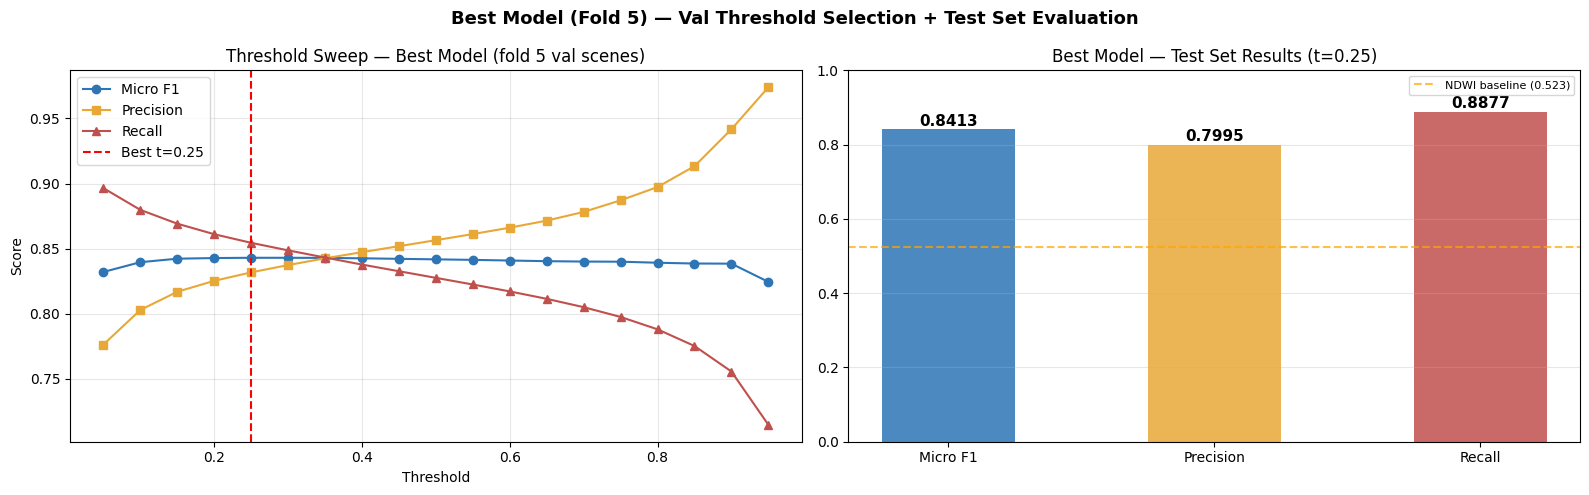


── Best Model Final Results ──
Threshold (from fold 5 val): 0.25
Test Micro F1:               0.8413
Test Precision:              0.7995
Test Recall:                 0.8877


In [18]:
# ── Cell 3b: Plot Threshold Sweep Results ──
sweep_val_best = sweep_df  # alias for compatibility

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(sweep_val_best['threshold'], sweep_val_best['micro_f1'],
             marker='o', color='#2E75B6', label='Micro F1')
axes[0].plot(sweep_val_best['threshold'], sweep_val_best['precision'],
             marker='s', color='#E8A838', label='Precision')
axes[0].plot(sweep_val_best['threshold'], sweep_val_best['recall'],
             marker='^', color='#C0504D', label='Recall')
axes[0].axvline(thresh_best_honest, color='red', linestyle='--',
                label=f'Best t={thresh_best_honest}')
axes[0].set_title('Threshold Sweep — Best Model (fold 5 val scenes)')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].legend(); axes[0].grid(alpha=0.3)

metrics = ['Micro F1', 'Precision', 'Recall']
values  = [f1_best_honest, p_best_honest, r_best_honest]
colors  = ['#2E75B6', '#E8A838', '#C0504D']
bars = axes[1].bar(metrics, values, color=colors, alpha=0.85, width=0.5)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[1].axhline(0.523, color='orange', linestyle='--', alpha=0.7,
                label='NDWI baseline (0.523)')
axes[1].set_ylim(0, 1.0)
axes[1].set_title(f'Best Model — Test Set Results (t={thresh_best_honest})')
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Best Model (Fold 5) — Val Threshold Selection + Test Set Evaluation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DIAG_DIR / 'threshold_sweep_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n── Best Model Final Results ──')
print(f'Threshold (from fold 5 val): {thresh_best_honest}')
print(f'Test Micro F1:               {f1_best_honest:.4f}')
print(f'Test Precision:              {p_best_honest:.4f}')
print(f'Test Recall:                 {r_best_honest:.4f}')

In [23]:
# ── Cell 3c-1: Fold 1 — Threshold Selection on Fold 1 Val Scenes ──
import random, json, torch, rasterio
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from sklearn.model_selection import KFold
from tqdm import tqdm
import segmentation_models_pytorch as smp

SEED    = 42
N_FOLDS = 5
FOLD_NUM = 1

BASE_DIR  = Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask')
CHIPS_DIR = BASE_DIR / 'images/chips_images/images'
MASKS_DIR = BASE_DIR / 'images/chips_masks/masks'
KFOLD_DIR = BASE_DIR / 'results/unet_training_v3/kfold'
DIAG_DIR  = BASE_DIR / 'results/unet_diagnostic_v3'
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

TEST_SCENES = {
    '12AUG30193433_sub2', '15JUL02193_sub_2', '16Sep2219_1b_Chiwawa',
    '16Sep2219_1b_Teanaway', 'UGR_2017_08_30_103001007046C600_AOI_1',
    'UGR_2021_07_21_10300100C2972100_AOI_1', 'Wenatchee_2014_08_27_10300100354F7A00_AOI',
    'Wenatchee_2016_08_16_10400100214F5200_AOI_1', 'Wenatchee_2019_07_26_104001004E554F00_AOI_1',
    'Wenatchee_2022_11_09_104001007E867900_AOI_1', 'Wenatchee_2025_02_07_103001010D0A1600_AOI_1',
    'cath_creek_2015_10_09_10300100496A4600_AOI_1', 'cath_creek_2018_12_05_1040010046BF9000_AOI_1',
}

def get_scene_id(filename):
    name = Path(filename).stem
    if '_clipped_' in name: return name.split('_clipped_')[0]
    if '_clip_' in name:    return name.split('_clip_')[0]
    return name

all_chips  = sorted(CHIPS_DIR.glob('*.tif'))
mask_stems = {m.stem for m in MASKS_DIR.glob('*.tif')}
scene_to_water = defaultdict(list)
scene_to_land  = defaultdict(list)
for chip in all_chips:
    if chip.stem not in mask_stems: continue
    sid = get_scene_id(chip.name)
    if sid in TEST_SCENES: continue
    with rasterio.open(MASKS_DIR / chip.name) as src:
        has_water = (src.read(1) > 0).any()
    if has_water:
        scene_to_water[sid].append(chip)
    else:
        scene_to_land[sid].append(chip)

scene_list = sorted(set(scene_to_water.keys()) | set(scene_to_land.keys()))
random.seed(SEED)
random.shuffle(scene_list)
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
all_splits = list(kf.split(scene_list))
train_idx, val_idx = all_splits[FOLD_NUM - 1]
val_scenes = set(scene_list[i] for i in val_idx)
val_chips  = [c for s in val_scenes
              for c in (scene_to_water.get(s,[]) + scene_to_land.get(s,[]))]
print(f'Fold {FOLD_NUM} val scenes: {len(val_scenes)} | val chips: {len(val_chips):,}')

with open(BASE_DIR / 'results/unet_training/normalisation_stats.json') as f:
    stats = json.load(f)
mean_t = torch.tensor(np.array(stats['mean'], dtype=np.float32)).view(4,1,1).to(DEVICE)
std_t  = torch.tensor(np.array(stats['std'],  dtype=np.float32)).view(4,1,1).to(DEVICE)

# ── Load FOLD 1 model ──
model = smp.Unet(
    encoder_name='resnet34', encoder_weights=None,
    in_channels=4, classes=1, activation=None,
).to(DEVICE)
model.load_state_dict(torch.load(KFOLD_DIR / f'fold{FOLD_NUM}_best.pth', map_location=DEVICE))
model.eval()

THRESHOLDS = [round(t, 2) for t in np.arange(0.05, 1.0, 0.05)]
tp_counts = {t: 0 for t in THRESHOLDS}
fp_counts = {t: 0 for t in THRESHOLDS}
fn_counts = {t: 0 for t in THRESHOLDS}

print(f'Running inference on fold {FOLD_NUM} val chips...')
with torch.no_grad():
    for chip_path in tqdm(val_chips):
        mask_path = MASKS_DIR / chip_path.name
        if not mask_path.exists(): continue
        with rasterio.open(chip_path) as src:
            image = np.stack([src.read(5), src.read(3), src.read(2), src.read(7)]).astype(np.float32)
        image_t = (torch.from_numpy(image).to(DEVICE) - mean_t) / std_t
        prob = torch.sigmoid(model(image_t.unsqueeze(0))).squeeze().cpu().numpy().flatten()
        with rasterio.open(mask_path) as src:
            truth = (src.read(1) > 0).astype(np.uint8).flatten()
        for t in THRESHOLDS:
            pred = (prob >= t).astype(np.uint8)
            tp_counts[t] += int(((pred==1)&(truth==1)).sum())
            fp_counts[t] += int(((pred==1)&(truth==0)).sum())
            fn_counts[t] += int(((pred==0)&(truth==1)).sum())

rows = []
for t in THRESHOLDS:
    tp, fp, fn = tp_counts[t], fp_counts[t], fn_counts[t]
    precision = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    recall    = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0.0
    rows.append({'threshold': t, 'micro_f1': round(f1,4),
                 'precision': round(precision,4), 'recall': round(recall,4)})

sweep_df = pd.DataFrame(rows)
best_idx  = sweep_df['micro_f1'].idxmax()
thresh_best = float(sweep_df.loc[best_idx, 'threshold'])
f1_best     = float(sweep_df.loc[best_idx, 'micro_f1'])
print(f'\n✓ Best threshold (fold {FOLD_NUM} val): t={thresh_best} | F1={f1_best:.4f}')

result = {'fold': FOLD_NUM, 'threshold': thresh_best, 'val_f1': f1_best}
with open(DIAG_DIR / f'fold{FOLD_NUM}_thresh.json', 'w') as f:
    json.dump(result, f, indent=2)
print(f'Saved: {DIAG_DIR}/fold{FOLD_NUM}_thresh.json')

Fold 1 val scenes: 11 | val chips: 2,514
Running inference on fold 1 val chips...


100%|██████████| 2514/2514 [14:55<00:00,  2.81it/s]


✓ Best threshold (fold 1 val): t=0.8 | F1=0.8949
Saved: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/unet_diagnostic_v3/fold1_thresh.json


In [24]:
# ── Cell 3c-2: Fold 2 — Threshold Selection on Fold 2 Val Scenes ──
FOLD_NUM = 2

all_chips  = sorted(CHIPS_DIR.glob('*.tif'))
scene_to_water = defaultdict(list)
scene_to_land  = defaultdict(list)
for chip in all_chips:
    if chip.stem not in mask_stems: continue
    sid = get_scene_id(chip.name)
    if sid in TEST_SCENES: continue
    with rasterio.open(MASKS_DIR / chip.name) as src:
        has_water = (src.read(1) > 0).any()
    if has_water:
        scene_to_water[sid].append(chip)
    else:
        scene_to_land[sid].append(chip)

scene_list = sorted(set(scene_to_water.keys()) | set(scene_to_land.keys()))
random.seed(SEED)
random.shuffle(scene_list)
all_splits = list(kf.split(scene_list))
train_idx, val_idx = all_splits[FOLD_NUM - 1]
val_scenes = set(scene_list[i] for i in val_idx)
val_chips  = [c for s in val_scenes
              for c in (scene_to_water.get(s,[]) + scene_to_land.get(s,[]))]
print(f'Fold {FOLD_NUM} val scenes: {len(val_scenes)} | val chips: {len(val_chips):,}')

# ── Load FOLD 2 model ──
model = smp.Unet(
    encoder_name='resnet34', encoder_weights=None,
    in_channels=4, classes=1, activation=None,
).to(DEVICE)
model.load_state_dict(torch.load(KFOLD_DIR / f'fold{FOLD_NUM}_best.pth', map_location=DEVICE))
model.eval()

tp_counts = {t: 0 for t in THRESHOLDS}
fp_counts = {t: 0 for t in THRESHOLDS}
fn_counts = {t: 0 for t in THRESHOLDS}

print(f'Running inference on fold {FOLD_NUM} val chips...')
with torch.no_grad():
    for chip_path in tqdm(val_chips):
        mask_path = MASKS_DIR / chip_path.name
        if not mask_path.exists(): continue
        with rasterio.open(chip_path) as src:
            image = np.stack([src.read(5), src.read(3), src.read(2), src.read(7)]).astype(np.float32)
        image_t = (torch.from_numpy(image).to(DEVICE) - mean_t) / std_t
        prob = torch.sigmoid(model(image_t.unsqueeze(0))).squeeze().cpu().numpy().flatten()
        with rasterio.open(mask_path) as src:
            truth = (src.read(1) > 0).astype(np.uint8).flatten()
        for t in THRESHOLDS:
            pred = (prob >= t).astype(np.uint8)
            tp_counts[t] += int(((pred==1)&(truth==1)).sum())
            fp_counts[t] += int(((pred==1)&(truth==0)).sum())
            fn_counts[t] += int(((pred==0)&(truth==1)).sum())

rows = []
for t in THRESHOLDS:
    tp, fp, fn = tp_counts[t], fp_counts[t], fn_counts[t]
    precision = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    recall    = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0.0
    rows.append({'threshold': t, 'micro_f1': round(f1,4),
                 'precision': round(precision,4), 'recall': round(recall,4)})

sweep_df = pd.DataFrame(rows)
best_idx  = sweep_df['micro_f1'].idxmax()
thresh_best = float(sweep_df.loc[best_idx, 'threshold'])
f1_best     = float(sweep_df.loc[best_idx, 'micro_f1'])
print(f'\n✓ Best threshold (fold {FOLD_NUM} val): t={thresh_best} | F1={f1_best:.4f}')

result = {'fold': FOLD_NUM, 'threshold': thresh_best, 'val_f1': f1_best}
with open(DIAG_DIR / f'fold{FOLD_NUM}_thresh.json', 'w') as f:
    json.dump(result, f, indent=2)
print(f'Saved: {DIAG_DIR}/fold{FOLD_NUM}_thresh.json')

Fold 2 val scenes: 10 | val chips: 2,455
Running inference on fold 2 val chips...


100%|██████████| 2455/2455 [14:17<00:00,  2.86it/s]


✓ Best threshold (fold 2 val): t=0.65 | F1=0.8610
Saved: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/unet_diagnostic_v3/fold2_thresh.json


In [25]:
# ── Cell 3c-3: Fold 3 — Threshold Selection on Fold 3 Val Scenes ──
FOLD_NUM = 3

scene_to_water = defaultdict(list)
scene_to_land  = defaultdict(list)
for chip in all_chips:
    if chip.stem not in mask_stems: continue
    sid = get_scene_id(chip.name)
    if sid in TEST_SCENES: continue
    with rasterio.open(MASKS_DIR / chip.name) as src:
        has_water = (src.read(1) > 0).any()
    if has_water:
        scene_to_water[sid].append(chip)
    else:
        scene_to_land[sid].append(chip)

scene_list = sorted(set(scene_to_water.keys()) | set(scene_to_land.keys()))
random.seed(SEED)
random.shuffle(scene_list)
all_splits = list(kf.split(scene_list))
train_idx, val_idx = all_splits[FOLD_NUM - 1]
val_scenes = set(scene_list[i] for i in val_idx)
val_chips  = [c for s in val_scenes
              for c in (scene_to_water.get(s,[]) + scene_to_land.get(s,[]))]
print(f'Fold {FOLD_NUM} val scenes: {len(val_scenes)} | val chips: {len(val_chips):,}')

# ── Load FOLD 3 model ──
model = smp.Unet(
    encoder_name='resnet34', encoder_weights=None,
    in_channels=4, classes=1, activation=None,
).to(DEVICE)
model.load_state_dict(torch.load(KFOLD_DIR / f'fold{FOLD_NUM}_best.pth', map_location=DEVICE))
model.eval()

tp_counts = {t: 0 for t in THRESHOLDS}
fp_counts = {t: 0 for t in THRESHOLDS}
fn_counts = {t: 0 for t in THRESHOLDS}

print(f'Running inference on fold {FOLD_NUM} val chips...')
with torch.no_grad():
    for chip_path in tqdm(val_chips):
        mask_path = MASKS_DIR / chip_path.name
        if not mask_path.exists(): continue
        with rasterio.open(chip_path) as src:
            image = np.stack([src.read(5), src.read(3), src.read(2), src.read(7)]).astype(np.float32)
        image_t = (torch.from_numpy(image).to(DEVICE) - mean_t) / std_t
        prob = torch.sigmoid(model(image_t.unsqueeze(0))).squeeze().cpu().numpy().flatten()
        with rasterio.open(mask_path) as src:
            truth = (src.read(1) > 0).astype(np.uint8).flatten()
        for t in THRESHOLDS:
            pred = (prob >= t).astype(np.uint8)
            tp_counts[t] += int(((pred==1)&(truth==1)).sum())
            fp_counts[t] += int(((pred==1)&(truth==0)).sum())
            fn_counts[t] += int(((pred==0)&(truth==1)).sum())

rows = []
for t in THRESHOLDS:
    tp, fp, fn = tp_counts[t], fp_counts[t], fn_counts[t]
    precision = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    recall    = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0.0
    rows.append({'threshold': t, 'micro_f1': round(f1,4),
                 'precision': round(precision,4), 'recall': round(recall,4)})

sweep_df = pd.DataFrame(rows)
best_idx  = sweep_df['micro_f1'].idxmax()
thresh_best = float(sweep_df.loc[best_idx, 'threshold'])
f1_best     = float(sweep_df.loc[best_idx, 'micro_f1'])
print(f'\n✓ Best threshold (fold {FOLD_NUM} val): t={thresh_best} | F1={f1_best:.4f}')

result = {'fold': FOLD_NUM, 'threshold': thresh_best, 'val_f1': f1_best}
with open(DIAG_DIR / f'fold{FOLD_NUM}_thresh.json', 'w') as f:
    json.dump(result, f, indent=2)
print(f'Saved: {DIAG_DIR}/fold{FOLD_NUM}_thresh.json')

Fold 3 val scenes: 10 | val chips: 1,866
Running inference on fold 3 val chips...


100%|██████████| 1866/1866 [10:45<00:00,  2.89it/s]


✓ Best threshold (fold 3 val): t=0.15 | F1=0.8885
Saved: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/unet_diagnostic_v3/fold3_thresh.json


In [26]:
# ── Cell 3c-4: Fold 4 — Threshold Selection on Fold 4 Val Scenes ──
FOLD_NUM = 4

scene_to_water = defaultdict(list)
scene_to_land  = defaultdict(list)
for chip in all_chips:
    if chip.stem not in mask_stems: continue
    sid = get_scene_id(chip.name)
    if sid in TEST_SCENES: continue
    with rasterio.open(MASKS_DIR / chip.name) as src:
        has_water = (src.read(1) > 0).any()
    if has_water:
        scene_to_water[sid].append(chip)
    else:
        scene_to_land[sid].append(chip)

scene_list = sorted(set(scene_to_water.keys()) | set(scene_to_land.keys()))
random.seed(SEED)
random.shuffle(scene_list)
all_splits = list(kf.split(scene_list))
train_idx, val_idx = all_splits[FOLD_NUM - 1]
val_scenes = set(scene_list[i] for i in val_idx)
val_chips  = [c for s in val_scenes
              for c in (scene_to_water.get(s,[]) + scene_to_land.get(s,[]))]
print(f'Fold {FOLD_NUM} val scenes: {len(val_scenes)} | val chips: {len(val_chips):,}')

# ── Load FOLD 4 model ──
model = smp.Unet(
    encoder_name='resnet34', encoder_weights=None,
    in_channels=4, classes=1, activation=None,
).to(DEVICE)
model.load_state_dict(torch.load(KFOLD_DIR / f'fold{FOLD_NUM}_best.pth', map_location=DEVICE))
model.eval()

tp_counts = {t: 0 for t in THRESHOLDS}
fp_counts = {t: 0 for t in THRESHOLDS}
fn_counts = {t: 0 for t in THRESHOLDS}

print(f'Running inference on fold {FOLD_NUM} val chips...')
with torch.no_grad():
    for chip_path in tqdm(val_chips):
        mask_path = MASKS_DIR / chip_path.name
        if not mask_path.exists(): continue
        with rasterio.open(chip_path) as src:
            image = np.stack([src.read(5), src.read(3), src.read(2), src.read(7)]).astype(np.float32)
        image_t = (torch.from_numpy(image).to(DEVICE) - mean_t) / std_t
        prob = torch.sigmoid(model(image_t.unsqueeze(0))).squeeze().cpu().numpy().flatten()
        with rasterio.open(mask_path) as src:
            truth = (src.read(1) > 0).astype(np.uint8).flatten()
        for t in THRESHOLDS:
            pred = (prob >= t).astype(np.uint8)
            tp_counts[t] += int(((pred==1)&(truth==1)).sum())
            fp_counts[t] += int(((pred==1)&(truth==0)).sum())
            fn_counts[t] += int(((pred==0)&(truth==1)).sum())

rows = []
for t in THRESHOLDS:
    tp, fp, fn = tp_counts[t], fp_counts[t], fn_counts[t]
    precision = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    recall    = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0.0
    rows.append({'threshold': t, 'micro_f1': round(f1,4),
                 'precision': round(precision,4), 'recall': round(recall,4)})

sweep_df = pd.DataFrame(rows)
best_idx  = sweep_df['micro_f1'].idxmax()
thresh_best = float(sweep_df.loc[best_idx, 'threshold'])
f1_best     = float(sweep_df.loc[best_idx, 'micro_f1'])
print(f'\n✓ Best threshold (fold {FOLD_NUM} val): t={thresh_best} | F1={f1_best:.4f}')

result = {'fold': FOLD_NUM, 'threshold': thresh_best, 'val_f1': f1_best}
with open(DIAG_DIR / f'fold{FOLD_NUM}_thresh.json', 'w') as f:
    json.dump(result, f, indent=2)
print(f'Saved: {DIAG_DIR}/fold{FOLD_NUM}_thresh.json')

Fold 4 val scenes: 10 | val chips: 2,273
Running inference on fold 4 val chips...


100%|██████████| 2273/2273 [12:43<00:00,  2.98it/s]


✓ Best threshold (fold 4 val): t=0.8 | F1=0.8022
Saved: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/unet_diagnostic_v3/fold4_thresh.json


In [27]:
# ── Cell 3c-6: Majority Vote Ensemble — Test Set Evaluation ──
# Loads per-fold thresholds from fold{N}_thresh.json (saved by Cell 3c-5).
# Each fold model applies its own val-selected threshold to produce a binary prediction.
# Majority vote: chip is water if 3 or more of the 5 models predict water.
# Binary predictions saved to pred_maps_ensemble_majority/ for downstream use.

import json, torch, rasterio
import numpy as np
import segmentation_models_pytorch as smp
from pathlib import Path
from sklearn.metrics import f1_score, precision_score, recall_score
from tqdm import tqdm

BASE_DIR  = Path('/mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask')
CHIPS_DIR = BASE_DIR / 'images/chips_images/images'
MASKS_DIR = BASE_DIR / 'images/chips_masks/masks'
KFOLD_DIR = BASE_DIR / 'results/unet_training_v3/kfold'
DIAG_DIR  = BASE_DIR / 'results/unet_diagnostic_v3'
PRED_DIR_MAJORITY = DIAG_DIR / 'pred_maps_ensemble_majority'
PRED_DIR_MAJORITY.mkdir(exist_ok=True)
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_FOLDS   = 5

with open(BASE_DIR / 'results/unet_training/test_chips.json') as f:
    test_chip_names = json.load(f)
test_chips = [CHIPS_DIR / n for n in test_chip_names]

with open(BASE_DIR / 'results/unet_training/normalisation_stats.json') as f:
    stats = json.load(f)
mean_t = torch.tensor(np.array(stats['mean'], dtype=np.float32)).view(4,1,1).to(DEVICE)
std_t  = torch.tensor(np.array(stats['std'],  dtype=np.float32)).view(4,1,1).to(DEVICE)

# Load per-fold thresholds
fold_thresholds = []
print('Per-fold thresholds:')
for fold_num in range(1, N_FOLDS + 1):
    with open(DIAG_DIR / f'fold{fold_num}_thresh.json') as f:
        result = json.load(f)
    fold_thresholds.append(result['threshold'])
    print(f'  Fold {fold_num}: t={result["threshold"]} | val F1={result["val_f1"]:.4f}')

# Load all fold models
print('\nLoading fold models...')
fold_models = []
for fold_num in range(1, N_FOLDS + 1):
    model = smp.Unet(encoder_name='resnet34', encoder_weights=None,
                     in_channels=4, classes=1, activation=None).to(DEVICE)
    model.load_state_dict(torch.load(KFOLD_DIR / f'fold{fold_num}_best.pth', map_location=DEVICE))
    model.eval()
    fold_models.append(model)
    print(f'  Loaded fold {fold_num}')

# Run majority vote on test set
print(f'\nRunning majority vote on {len(test_chips):,} test chips...')
all_preds, all_truths = [], []

with torch.no_grad():
    for chip_path in tqdm(test_chips):
        mask_path = MASKS_DIR / chip_path.name
        pred_path = PRED_DIR_MAJORITY / chip_path.name
        if not mask_path.exists(): continue

        with rasterio.open(chip_path) as src:
            image   = np.stack([src.read(5), src.read(3),
                                src.read(2), src.read(7)]).astype(np.float32)
            profile = src.profile.copy()
        profile.update(count=1, dtype='uint8', nodata=None)
        image_t = (torch.from_numpy(image).to(DEVICE) - mean_t) / std_t

        votes = np.zeros((512, 512), dtype=np.int32)
        for model, thresh in zip(fold_models, fold_thresholds):
            prob = torch.sigmoid(model(image_t.unsqueeze(0))).squeeze().cpu().numpy()
            votes += (prob >= thresh).astype(np.int32)

        pred = (votes >= 3).astype(np.uint8)

        if not pred_path.exists():
            with rasterio.open(pred_path, 'w', **profile) as dst:
                dst.write(pred[np.newaxis, :, :])

        with rasterio.open(mask_path) as src:
            truth = (src.read(1) > 0).astype(np.uint8).flatten()

        all_preds.append(pred.flatten())
        all_truths.append(truth)

p = np.concatenate(all_preds)
t = np.concatenate(all_truths)

f1_ens_majority = round(f1_score(t, p, zero_division=0), 4)
p_ens_majority  = round(precision_score(t, p, zero_division=0), 4)
r_ens_majority  = round(recall_score(t, p, zero_division=0), 4)

print(f'\n── Ensemble Majority Vote — Final Results ──')
print(f'Micro F1:   {f1_ens_majority:.4f}')
print(f'Precision:  {p_ens_majority:.4f}')
print(f'Recall:     {r_ens_majority:.4f}')
print(f'Per-fold thresholds: {fold_thresholds}')
print(f'\nNDWI baseline (dev):         F1=0.523')
print(f'Best model (fold 5 val):     F1=0.8413')
print(f'Improvement over NDWI (dev): +{f1_ens_majority - 0.523:.4f}')

# Variables for downstream cells
f1_ens_honest  = f1_ens_majority
p_ens_honest   = p_ens_majority
r_ens_honest   = r_ens_majority
thresh_ens_honest = fold_thresholds

# Also restore best model variables for downstream cells
thresh_best_honest = 0.25
f1_best_honest     = 0.8413
p_best_honest      = 0.7995
r_best_honest      = 0.8877

print('\n✓ All variables set for downstream cells 4–8.')

Per-fold thresholds:
  Fold 1: t=0.8 | val F1=0.8949
  Fold 2: t=0.65 | val F1=0.8610
  Fold 3: t=0.15 | val F1=0.8885
  Fold 4: t=0.8 | val F1=0.8022
  Fold 5: t=0.25 | val F1=0.8430

Loading fold models...
  Loaded fold 1
  Loaded fold 2
  Loaded fold 3
  Loaded fold 4
  Loaded fold 5

Running majority vote on 4,788 test chips...


 62%|██████▏   | 2992/4788 [23:10<14:13,  2.11it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)




── best_model (t=0.25) ──
                                       scene  chips  water_frac  micro_f1  precision  recall
cath_creek_2018_12_05_1040010046BF9000_AOI_1    319      0.0027    0.3907     0.3846  0.3971
 Wenatchee_2025_02_07_103001010D0A1600_AOI_1    338      0.0180    0.4634     0.3068  0.9460
                          12AUG30193433_sub2    125      0.0039    0.4706     0.3158  0.9234
cath_creek_2015_10_09_10300100496A4600_AOI_1    359      0.0053    0.6119     0.4774  0.8520
                       16Sep2219_1b_Teanaway    111      0.0035    0.6751     0.6073  0.7598
       UGR_2017_08_30_103001007046C600_AOI_1    384      0.0041    0.7614     0.7307  0.7947
       UGR_2021_07_21_10300100C2972100_AOI_1    168      0.0068    0.8516     0.8942  0.8129
                        16Sep2219_1b_Chiwawa    169      0.0186    0.8761     0.8620  0.8907
 Wenatchee_2022_11_09_104001007E867900_AOI_1    760      0.0825    0.8978     0.9363  0.8623
 Wenatchee_2016_08_16_10400100214F5200_AOI_

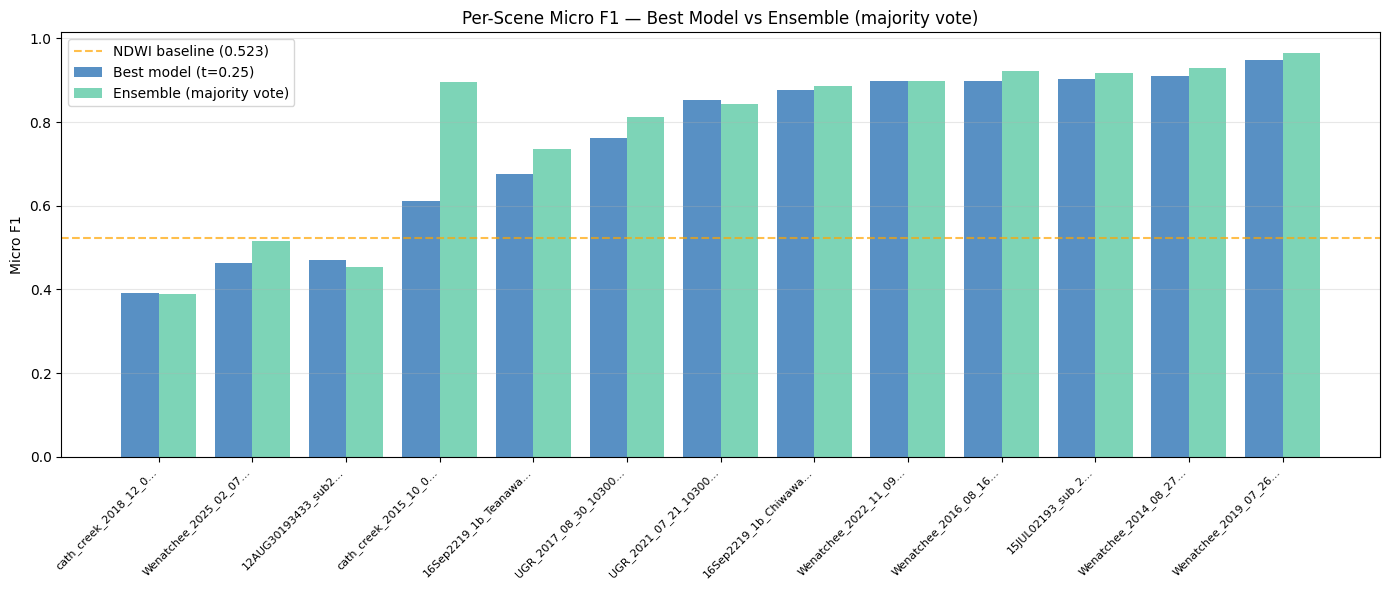

In [3]:
# ── Cell 4: Per-Scene Analysis ──
# Best model: uses PROB_DIR_BEST + thresh_best_honest
# Ensemble:   uses PRED_DIR_MAJORITY (binary predictions from majority vote)

from sklearn.metrics import f1_score, jaccard_score, precision_score, recall_score
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

PROB_DIR_BEST = DIAG_DIR / 'prob_maps_best'  
PRED_DIR_MAJORITY = DIAG_DIR / 'pred_maps_ensemble_majority'

def get_scene_id(filename):
    name = Path(filename).stem
    if '_clipped_' in name: return name.split('_clipped_')[0]
    if '_clip_' in name:    return name.split('_clip_')[0]
    return name
    
def per_scene_analysis_prob(prob_dir, thresh, label):
    """For best model — reads probability maps and applies threshold."""
    scene_to_chips = defaultdict(list)
    for c in test_chips:
        scene_to_chips[get_scene_id(c.name)].append(c)
    rows = []
    for scene_id, chips in scene_to_chips.items():
        all_preds, all_truths = [], []
        for chip_path in chips:
            prob_path = prob_dir / chip_path.name
            mask_path = MASKS_DIR / chip_path.name
            if not prob_path.exists(): continue
            with rasterio.open(prob_path) as src:
                prob = src.read(1)
            with rasterio.open(mask_path) as src:
                truth = (src.read(1) > 0).astype(np.uint8)
            all_preds.append((prob >= thresh).astype(np.uint8).flatten())
            all_truths.append(truth.flatten())
        p = np.concatenate(all_preds)
        t = np.concatenate(all_truths)
        rows.append({
            'scene':      scene_id,
            'chips':      len(chips),
            'water_frac': round(float(t.mean()), 4),
            'micro_f1':   round(f1_score(t, p, zero_division=0), 4),
            'precision':  round(precision_score(t, p, zero_division=0), 4),
            'recall':     round(recall_score(t, p, zero_division=0), 4),
            'iou':        round(jaccard_score(t, p, zero_division=0), 4),
        })
    df = pd.DataFrame(rows).sort_values('micro_f1')
    df.to_csv(DIAG_DIR / f'per_scene_{label}.csv', index=False)
    print(f'\n── {label} (t={thresh}) ──')
    print(df[['scene','chips','water_frac','micro_f1','precision','recall']].to_string(index=False))
    return df

def per_scene_analysis_binary(pred_dir, label):
    """For ensemble majority vote — reads binary prediction maps directly."""
    scene_to_chips = defaultdict(list)
    for c in test_chips:
        scene_to_chips[get_scene_id(c.name)].append(c)
    rows = []
    for scene_id, chips in scene_to_chips.items():
        all_preds, all_truths = [], []
        for chip_path in chips:
            pred_path = pred_dir / chip_path.name
            mask_path = MASKS_DIR / chip_path.name
            if not pred_path.exists(): continue
            with rasterio.open(pred_path) as src:
                pred = src.read(1).flatten()
            with rasterio.open(mask_path) as src:
                truth = (src.read(1) > 0).astype(np.uint8).flatten()
            all_preds.append(pred)
            all_truths.append(truth)
        p = np.concatenate(all_preds)
        t = np.concatenate(all_truths)
        rows.append({
            'scene':      scene_id,
            'chips':      len(chips),
            'water_frac': round(float(t.mean()), 4),
            'micro_f1':   round(f1_score(t, p, zero_division=0), 4),
            'precision':  round(precision_score(t, p, zero_division=0), 4),
            'recall':     round(recall_score(t, p, zero_division=0), 4),
            'iou':        round(jaccard_score(t, p, zero_division=0), 4),
        })
    df = pd.DataFrame(rows).sort_values('micro_f1')
    df.to_csv(DIAG_DIR / f'per_scene_{label}.csv', index=False)
    print(f'\n── {label} (majority vote) ──')
    print(df[['scene','chips','water_frac','micro_f1','precision','recall']].to_string(index=False))
    return df

scene_df_best = per_scene_analysis_prob(PROB_DIR_BEST, thresh_best_honest, 'best_model')
scene_df_ens  = per_scene_analysis_binary(PRED_DIR_MAJORITY, 'ensemble')

# Side-by-side bar chart
scenes = scene_df_best.sort_values('micro_f1')['scene'].tolist()
f1_b   = scene_df_best.set_index('scene').loc[scenes, 'micro_f1'].values
f1_e   = scene_df_ens.set_index('scene').loc[scenes, 'micro_f1'].values

x = np.arange(len(scenes))
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - 0.2, f1_b, 0.4, label=f'Best model (t={thresh_best_honest})',
       color='#2E75B6', alpha=0.8)
ax.bar(x + 0.2, f1_e, 0.4, label='Ensemble (majority vote)',
       color='#5DCAA5', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([s[:20]+'...' for s in scenes], rotation=45, ha='right', fontsize=8)
ax.axhline(0.523, color='orange', linestyle='--', alpha=0.7, label='NDWI baseline (0.523)')
ax.set_ylabel('Micro F1')
ax.set_title('Per-Scene Micro F1 — Best Model vs Ensemble (majority vote)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(DIAG_DIR / 'per_scene_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ── Cell 5: Probability Distribution Analysis ──

def prob_distributions(prob_dir, label):
    water_probs, land_probs = [], []
    for chip_path in tqdm(test_chips, desc=f'Distributions — {label}'):
        prob_path = prob_dir / chip_path.name
        mask_path = MASKS_DIR / chip_path.name
        if not prob_path.exists(): continue
        with rasterio.open(prob_path) as src:
            prob = src.read(1).flatten()
        with rasterio.open(mask_path) as src:
            truth = (src.read(1) > 0).flatten()
        water_probs.extend(prob[truth == 1].tolist())
        land_probs.extend(prob[truth == 0][:500].tolist())
    return np.array(water_probs), np.array(land_probs)

water_best, land_best = prob_distributions(PROB_DIR_BEST,     'best_model')
PROB_DIR_ENSEMBLE = DIAG_DIR / 'prob_maps_ensemble'
water_ens,  land_ens  = prob_distributions(PROB_DIR_ENSEMBLE, 'ensemble')

print(f'Best model — water mean: {water_best.mean():.4f} | land mean: {land_best.mean():.4f} | separation: {water_best.mean()-land_best.mean():.4f}')
print(f'Ensemble   — water mean: {water_ens.mean():.4f} | land mean: {land_ens.mean():.4f} | separation: {water_ens.mean()-land_ens.mean():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, water, land, thresh, label in [
    (axes[0], water_best, land_best, thresh_best_honest,                'Best model'),
    (axes[1], water_ens,  land_ens,  float(np.mean(thresh_ens_honest)), 'Ensemble (avg prob)'),
]:
    ax.hist(water, bins=50, color='steelblue', alpha=0.7,
            label=f'Water (mean={water.mean():.3f})', density=True)
    ax.hist(land,  bins=50, color='orange',    alpha=0.7,
            label=f'Land (mean={land.mean():.3f})',  density=True)
    ax.axvline(float(thresh), color='red', linestyle='--',
               label=f'Optimal t={float(thresh):.2f}')
    ax.set_title(f'{label} — Probability Distribution')
    ax.set_xlabel('Predicted probability'); ax.set_ylabel('Density')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Probability Calibration — Best Model vs Ensemble',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(DIAG_DIR / 'prob_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Distributions — best_model:  63%|██████▎   | 2999/4788 [14:46<09:55,  3.01it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



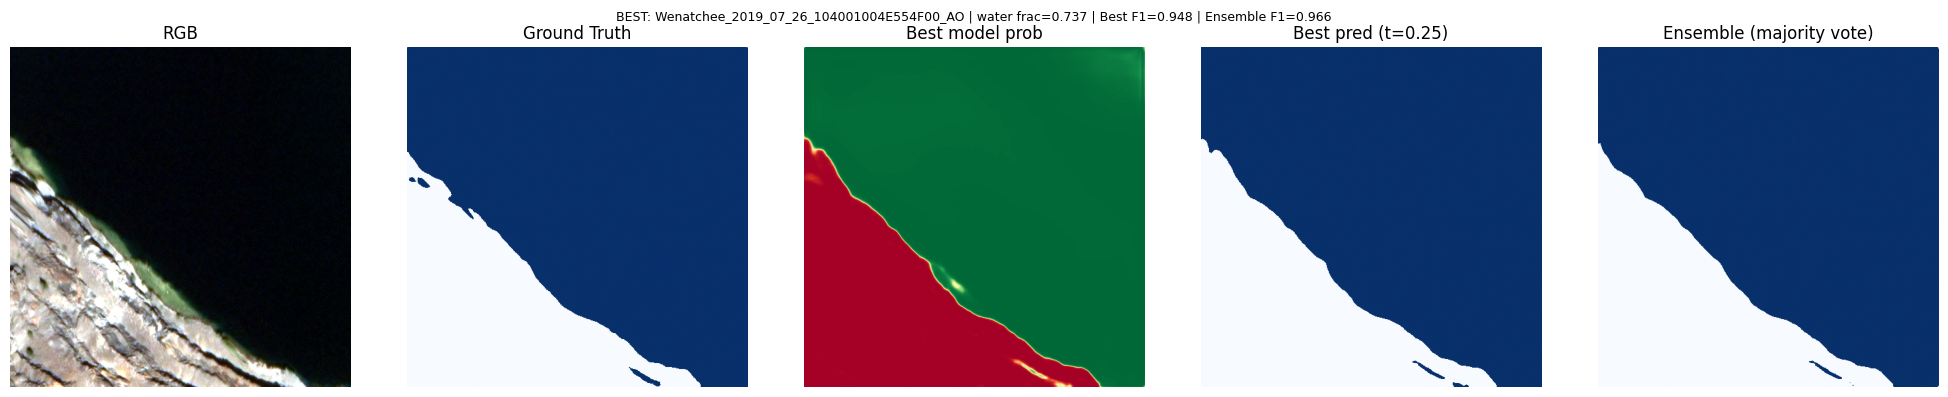

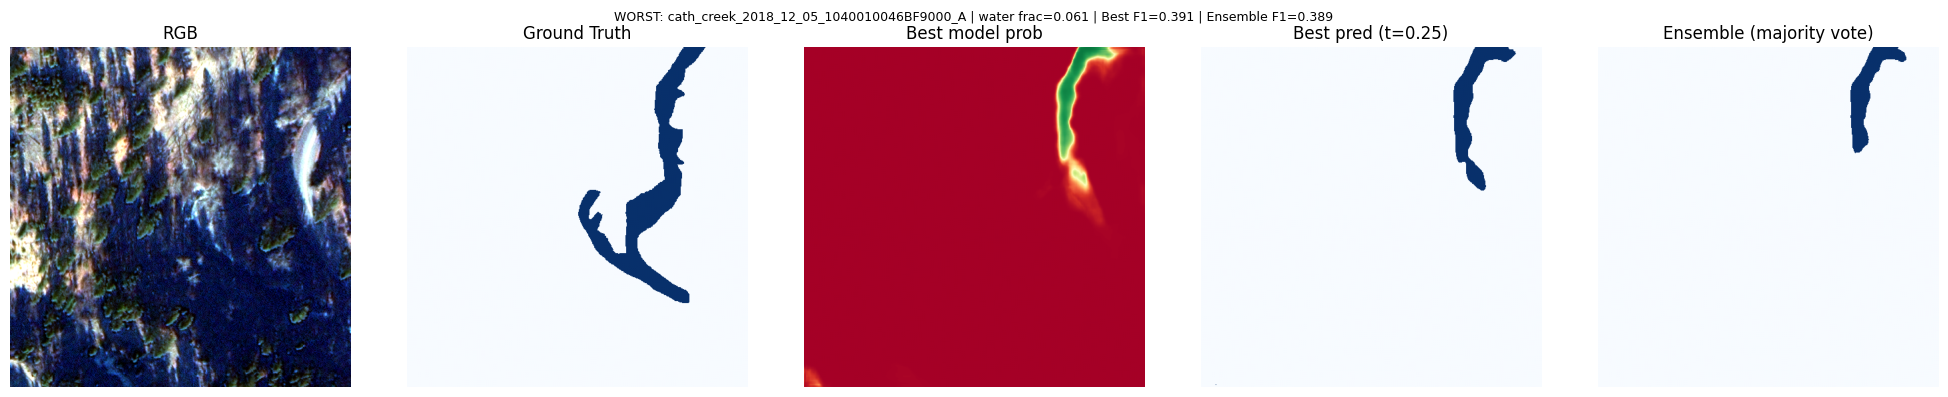

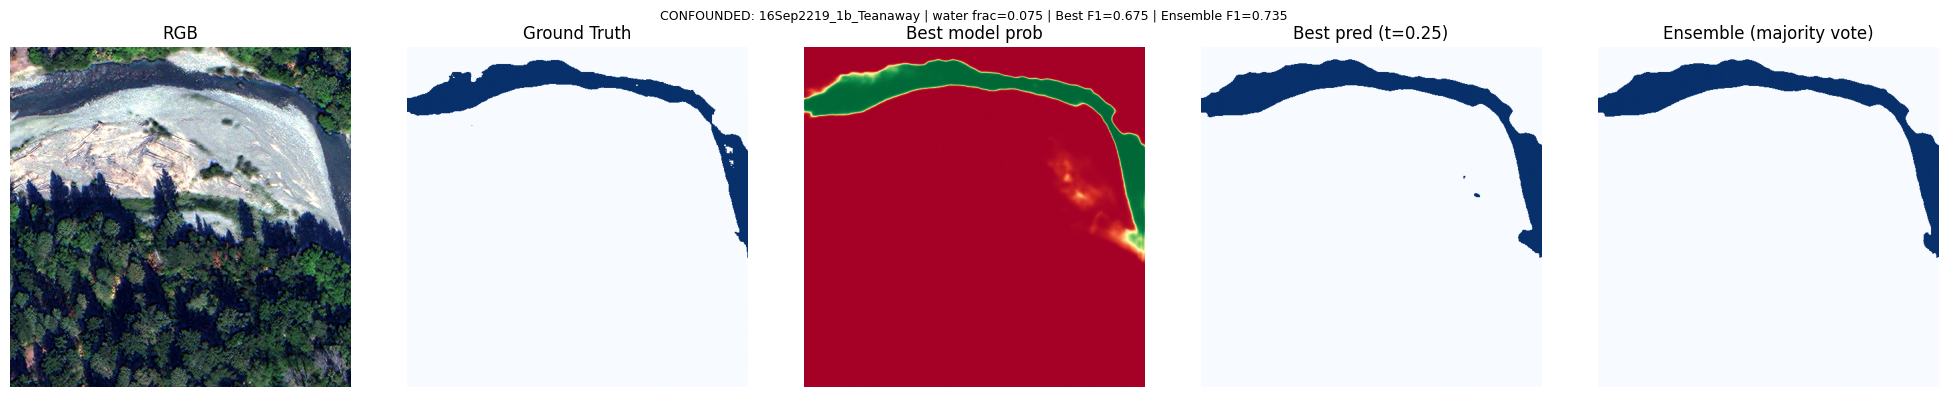

In [5]:
# ── Cell 6: Visual Inspection — Best, Worst and Confounded Scenes ──
# Fixed qualitative scenes; for each, the chip with the highest water fraction is
# shown so panels are informative (not empty land tiles). RGB is contrast-stretched.
# Columns: RGB | Ground Truth | Best model prob | Best pred | Ensemble (majority vote)
VISUALS_DIR       = DIAG_DIR / 'visuals'
PRED_DIR_MAJORITY = DIAG_DIR / 'pred_maps_ensemble_majority'
VISUALS_DIR.mkdir(exist_ok=True)

SCENES = [
    ('best',       'Wenatchee_2019_07_26_104001004E554F00_AOI_1'),
    ('worst',      'cath_creek_2018_12_05_1040010046BF9000_AOI_1'),
    ('confounded', '16Sep2219_1b_Teanaway'),
]

def stretch(arr):
    p2, p98 = np.percentile(arr, 2), np.percentile(arr, 98)
    if (p98 - p2) < 1:                                    # flat/dark chip fallback
        return np.clip(arr / max(arr.max(), 1) * 255, 0, 255).astype(np.uint8)
    return np.clip((arr - p2) / (p98 - p2) * 255, 0, 255).astype(np.uint8)

scene_to_chips_map = defaultdict(list)
for c in test_chips:
    scene_to_chips_map[get_scene_id(c.name)].append(c)

best_f1 = scene_df_best.set_index('scene')['micro_f1']
ens_f1  = scene_df_ens.set_index('scene')['micro_f1']

for label, scene_id in SCENES:
    # pick the chip with the highest water fraction (informative, not empty)
    candidates = []
    for cp in scene_to_chips_map.get(scene_id, []):
        if not (PROB_DIR_BEST / cp.name).exists():     continue
        if not (PRED_DIR_MAJORITY / cp.name).exists(): continue
        if not (MASKS_DIR / cp.name).exists():         continue
        with rasterio.open(MASKS_DIR / cp.name) as src:
            wf = float((src.read(1) > 0).mean())
        candidates.append((wf, cp))
    if not candidates:
        print(f'WARNING: no valid chip found for {scene_id}')
        continue
    wf, chip_path = max(candidates, key=lambda x: x[0])

    f1_b = best_f1.get(scene_id, float('nan'))
    f1_e = ens_f1.get(scene_id, float('nan'))

    with rasterio.open(chip_path) as src:
        rgb = np.stack([stretch(src.read(5).astype(np.float32)),
                        stretch(src.read(3).astype(np.float32)),
                        stretch(src.read(2).astype(np.float32))], axis=-1)
    with rasterio.open(MASKS_DIR / chip_path.name) as src:
        truth = (src.read(1) > 0).astype(np.uint8)
    with rasterio.open(PROB_DIR_BEST / chip_path.name) as src:
        prob_b = src.read(1)
    with rasterio.open(PRED_DIR_MAJORITY / chip_path.name) as src:
        pred_e = src.read(1)
    pred_b = (prob_b >= thresh_best_honest).astype(np.uint8)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    axes[0].imshow(rgb);                                   axes[0].set_title('RGB')
    axes[1].imshow(truth,  cmap='Blues',  vmin=0, vmax=1); axes[1].set_title('Ground Truth')
    axes[2].imshow(prob_b, cmap='RdYlGn', vmin=0, vmax=1); axes[2].set_title('Best model prob')
    axes[3].imshow(pred_b, cmap='Blues',  vmin=0, vmax=1); axes[3].set_title(f'Best pred (t={thresh_best_honest})')
    axes[4].imshow(pred_e, cmap='Blues',  vmin=0, vmax=1); axes[4].set_title('Ensemble (majority vote)')
    for ax in axes: ax.axis('off')
    plt.suptitle(f'{label.upper()}: {scene_id[:40]} | water frac={wf:.3f} | '
                 f'Best F1={f1_b:.3f} | Ensemble F1={f1_e:.3f}', fontsize=9)
    plt.tight_layout()
    plt.savefig(VISUALS_DIR / f'visual_{label}_{chip_path.stem[:30]}.png',
                dpi=100, bbox_inches='tight')
    plt.show()

In [31]:
# ── Cell 7: Final Summary ──
# Uses honest threshold variables from cells 3 and 3c.
# Saves final_summary.csv for comparison_all_final.ipynb.

summary_rows = [
    {'method': 'U-Net best model',
     'threshold': thresh_best_honest,
     'micro_f1':  f1_best_honest,
     'precision': p_best_honest,
     'recall':    r_best_honest,
     'threshold_source': 'fold 5 val scenes'},
    {'method': 'U-Net ensemble (majority vote)',
     'threshold': str(thresh_ens_honest),
     'micro_f1':  f1_ens_honest,
     'precision': p_ens_honest,
     'recall':    r_ens_honest,
     'threshold_source': 'per-fold val scenes (majority vote)'},
    {'method': 'NDWI (t=0.35, dev)',
     'threshold': 0.35,
     'micro_f1':  0.523,
     'precision': 0.376,
     'recall':    0.859,
     'threshold_source': '51 dev scenes'},
    {'method': 'OWM',
     'threshold': None,
     'micro_f1':  0.344,
     'precision': 0.209,
     'recall':    0.966,
     'threshold_source': 'OSM/NHD calibration'},
]

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(DIAG_DIR / 'final_summary.csv', index=False)

print('\n' + '='*70)
print('FINAL DIAGNOSTIC SUMMARY — HONEST THRESHOLDS')
print('='*70)
print(summary_df[['method','threshold','micro_f1','precision','recall',
                  'threshold_source']].to_string(index=False))
print(f'\nEnsemble vs best model: '
      f'{"BETTER" if f1_ens_honest > f1_best_honest else "SAME OR WORSE"} '
      f'(+{f1_ens_honest - f1_best_honest:.4f})')
print(f'Best U-Net vs NDWI (dev): '
      f'{"BETTER" if max(f1_best_honest, f1_ens_honest) > 0.523 else "WORSE"} '
      f'(+{max(f1_best_honest, f1_ens_honest) - 0.523:.4f})')
print(f'\nAll results saved to: {DIAG_DIR}')
print(f'Pass final_summary.csv to comparison_all_final.ipynb')


FINAL DIAGNOSTIC SUMMARY — HONEST THRESHOLDS
                        method                    threshold  micro_f1  precision  recall                    threshold_source
              U-Net best model                         0.25    0.8413     0.7995  0.8877                   fold 5 val scenes
U-Net ensemble (majority vote) [0.8, 0.65, 0.15, 0.8, 0.25]    0.8629     0.8392  0.8879 per-fold val scenes (majority vote)
            NDWI (t=0.35, dev)                         0.35    0.5230     0.3760  0.8590                       51 dev scenes
                           OWM                         None    0.3440     0.2090  0.9660                 OSM/NHD calibration

Ensemble vs best model: BETTER (+0.0216)
Best U-Net vs NDWI (dev): BETTER (+0.3399)

All results saved to: /mnt/batch/tasks/shared/LS_root/mounts/clusters/v-lmarotti1/code/Users/v-lmarotti/OmniWaterMask/results/unet_diagnostic_v3
Pass final_summary.csv to comparison_all_final.ipynb


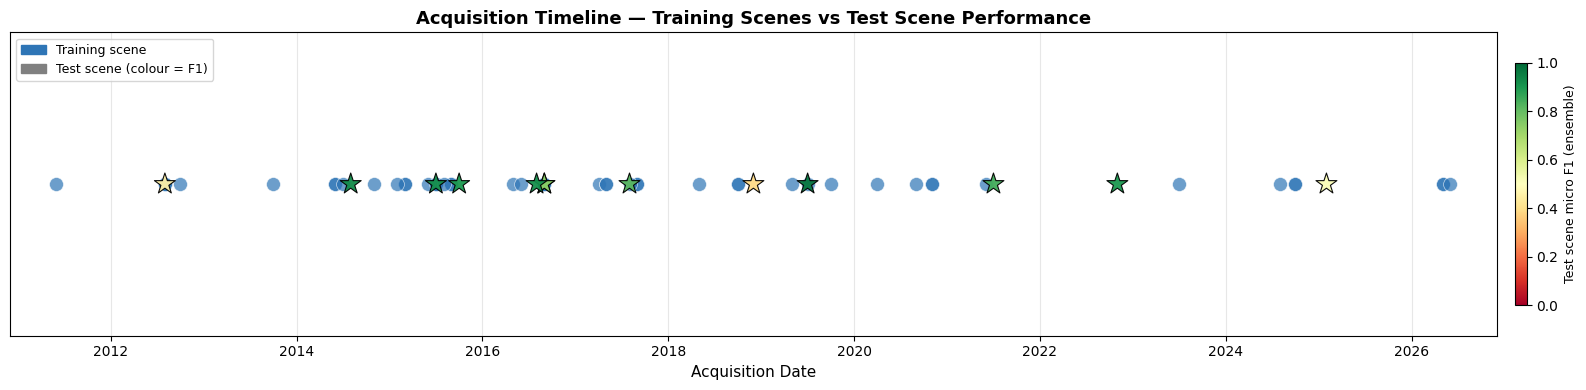

Saved fig_timeline_performance.png


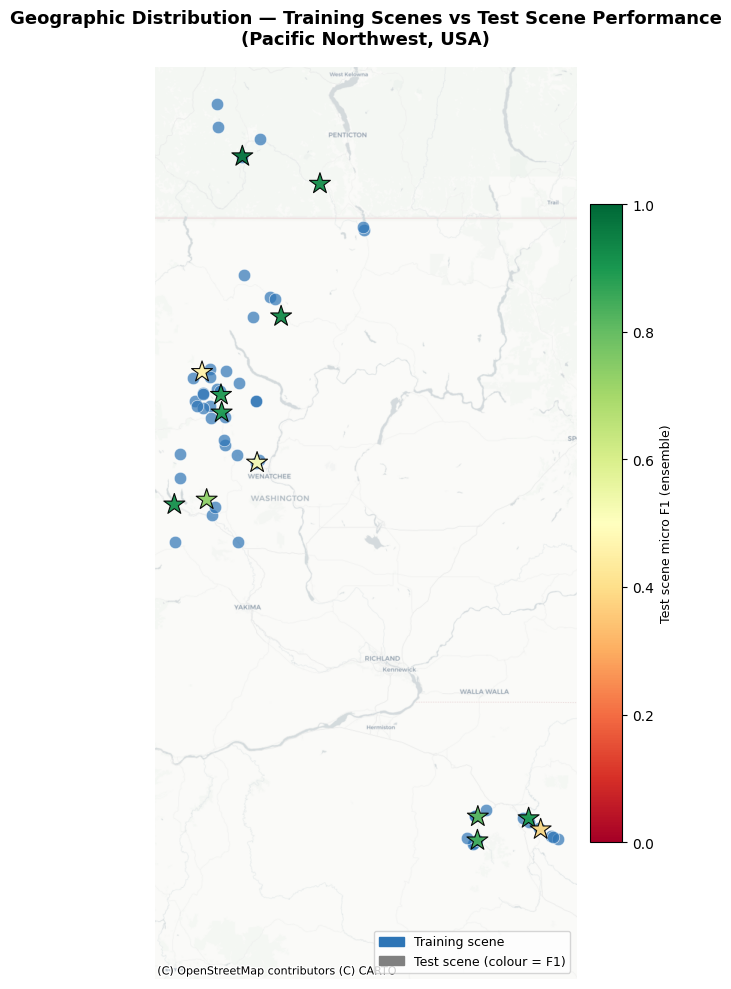

Saved fig_map_performance.png

── Test scene performance summary (ensemble) ──
                                       scene  year  month season  water_frac  micro_f1
cath_creek_2018_12_05_1040010046BF9000_AOI_1  2018     12 Winter    0.002743    0.3893
                          12AUG30193433_sub2  2012      8 Summer    0.003885    0.4541
 Wenatchee_2025_02_07_103001010D0A1600_AOI_1  2025      2 Winter    0.017965    0.5151
                       16Sep2219_1b_Teanaway  2016      9 Autumn    0.003526    0.7354
       UGR_2017_08_30_103001007046C600_AOI_1  2017      8 Summer    0.004128    0.8129
       UGR_2021_07_21_10300100C2972100_AOI_1  2021      7 Summer    0.006751    0.8439
                        16Sep2219_1b_Chiwawa  2016      9 Autumn    0.018645    0.8864
cath_creek_2015_10_09_10300100496A4600_AOI_1  2015     10 Autumn    0.005330    0.8963
 Wenatchee_2022_11_09_104001007E867900_AOI_1  2022     11 Autumn    0.082530    0.8978
                            15JUL02193_sub_2  2015 

In [32]:
# ── Cell 8: Timeline + Map — Test Scene Performance vs Training Distribution ──
# Requires: dataset_analysis.ipynb to have been run first (produces scene_metadata.csv)
# Uses ensemble per-scene results as the primary performance metric.

import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point

ANALYSIS_DIR = BASE_DIR / 'results/dataset_analysis'

# Load scene metadata
scene_meta = pd.read_csv(ANALYSIS_DIR / 'scene_metadata.csv')

# Load per-scene ensemble results
scene_ens = pd.read_csv(DIAG_DIR / 'per_scene_ensemble.csv')

# Merge
df = scene_meta.merge(scene_ens[['scene','micro_f1']], on='scene', how='left')
train_df = df[df['split'] == 'train/val'].copy()
test_df  = df[df['split'] == 'test'].copy()

# Colour map
cmap = cm.RdYlGn
norm = mcolors.Normalize(vmin=0, vmax=1)
sm   = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

def f1_color(f1):
    if pd.isna(f1): return 'grey'
    return cmap(norm(f1))

# ════════════════════════════════════════════════════════════
# FIGURE A — Timeline
# ════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(18, 4))

train_valid = train_df[train_df['year'].notna()].copy()
train_valid['date_num'] = train_valid['year'] + (train_valid['month'] - 1) / 12

test_valid = test_df[test_df['year'].notna()].copy()
test_valid['date_num'] = test_valid['year'] + (test_valid['month'] - 1) / 12

# Train scenes — blue dots
ax.scatter(train_valid['date_num'], [0]*len(train_valid),
           c='#2E75B6', s=100, alpha=0.7, zorder=3,
           label='Training scene', marker='o',
           edgecolors='white', linewidths=0.5)

# Test scenes — coloured by F1, overlaid on same y=0
colors_test = [f1_color(f) for f in test_valid['micro_f1']]
ax.scatter(test_valid['date_num'], [0]*len(test_valid),
           c=colors_test, s=250, alpha=0.95, zorder=4,
           edgecolors='black', linewidths=0.8, marker='*')

# No labels on test scenes
ax.set_yticks([])
ax.set_xlabel('Acquisition Date', fontsize=11)
ax.set_xlim(train_valid['date_num'].min() - 0.5,
            max(train_valid['date_num'].max(),
                test_valid['date_num'].max()) + 0.5)
ax.set_ylim(-0.5, 0.5)
ax.grid(axis='x', alpha=0.3)

cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.01, shrink=0.8)
cbar.set_label('Test scene micro F1 (ensemble)', fontsize=9)

train_patch = mpatches.Patch(color='#2E75B6', label='Training scene')
test_patch  = mpatches.Patch(color='grey',    label='Test scene (colour = F1)')
ax.legend(handles=[train_patch, test_patch], loc='upper left', fontsize=9)

plt.title('Acquisition Timeline — Training Scenes vs Test Scene Performance',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DIAG_DIR / 'fig_timeline_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_timeline_performance.png')

# ════════════════════════════════════════════════════════════
# FIGURE B — Geographic Map with basemap
# ════════════════════════════════════════════════════════════

df_geo    = df[df['lat'].notna() & df['lon'].notna()].copy()
train_geo = df_geo[df_geo['split'] == 'train/val']
test_geo  = df_geo[df_geo['split'] == 'test'].copy()

# Convert to GeoDataFrame in Web Mercator
geometry_train = [Point(lon, lat) for lon, lat in
                  zip(train_geo['lon'], train_geo['lat'])]
geometry_test  = [Point(lon, lat) for lon, lat in
                  zip(test_geo['lon'], test_geo['lat'])]

gdf_train = gpd.GeoDataFrame(train_geo, geometry=geometry_train,
                              crs='EPSG:4326').to_crs('EPSG:3857')
gdf_test  = gpd.GeoDataFrame(test_geo,  geometry=geometry_test,
                              crs='EPSG:4326').to_crs('EPSG:3857')

fig, ax = plt.subplots(figsize=(14, 10))

# Train scenes
gdf_train.plot(ax=ax, color='#2E75B6', markersize=80, alpha=0.7,
               marker='o', edgecolors='white', linewidths=0.5,
               label='Training scene', zorder=3)

# Test scenes — coloured by F1
colors_map = [f1_color(f) for f in gdf_test['micro_f1']]
gdf_test.plot(ax=ax, color=colors_map, markersize=250, alpha=0.95,
              marker='*', edgecolors='black', linewidths=0.8, zorder=4)

# Basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=8)

# Add padding below the southernmost point
xmin, ymin, xmax, ymax = ax.get_xlim()[0], ax.get_ylim()[0], ax.get_xlim()[1], ax.get_ylim()[1]
y_padding = (ymax - ymin) * 0.12
ax.set_ylim(ymin - y_padding, ymax)

# Colourbar
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.01, shrink=0.7)
cbar.set_label('Test scene micro F1 (ensemble)', fontsize=9)

# Legend
train_patch = mpatches.Patch(color='#2E75B6', label='Training scene')
test_patch  = mpatches.Patch(color='grey',    label='Test scene (colour = F1)')
ax.legend(handles=[train_patch, test_patch], loc='lower right', fontsize=9)

ax.set_axis_off()
ax.set_title('Geographic Distribution — Training Scenes vs Test Scene Performance\n(Pacific Northwest, USA)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DIAG_DIR / 'fig_map_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_map_performance.png')

# Summary table
print('\n── Test scene performance summary (ensemble) ──')
print(test_df[['scene','year','month','season','water_frac','micro_f1']]
      .sort_values('micro_f1')
      .to_string(index=False))